In [2]:
import numpy as np
import torch
from skimage import io, transform
from segment_anything import sam_model_registry
import matplotlib.pyplot as plt
import os
import SimpleITK as sitk
from pathlib import Path
import glob
from PIL import Image

from torch.utils.data import DataLoader
from torch.utils.data import Subset
from torchvision import transforms, datasets
from pytorch_ood.detector import Mahalanobis
from pytorch_ood.utils import OODMetrics, ToUnknown, fix_random_seed

from torch.utils.data import Dataset
import torchvision.transforms.functional as TF
from torchvision.io import decode_image

from collections import defaultdict
import random

In [3]:
device = "cuda:1"
ckpt = "../work_dir/MedSAM/medsam_vit_b.pth"

# build model WITHOUT checkpoint
model = sam_model_registry["vit_b"](checkpoint=None)

# load checkpoint safely on CPU
state_dict = torch.load(ckpt, map_location="cpu")

# load weights into model
model.load_state_dict(state_dict)

# now move model to the target GPU
model = model.to(device).eval()

In [4]:
class PatchDataset(Dataset):
    def __init__(
        self,
        root,
        domains,
        label,
        split="all",
        train_ratio=0.7,
        seed=123,
        transform=None,
        limit_images=None,
    ):
        """
        Parameters
        ----------
        root : str or Path
            Root directory containing domain folders.
        domains : list[str]
            Which domains to include, e.g. ["1a"] or ["2", "3", "4"].
        label : int
            Label to assign to all samples from these domains.
            Use 0 for ID, -1 for OOD.
        split : str
            "train", "test", or "all"
        train_ratio : float
            Fraction of source images used for train split.
        seed : int
            Random seed for reproducible splitting at source-image level.
        transform : callable or None
            Optional transform applied to image tensor.
        limit_images : int or None
            Optional limit on number of source images per dataset.
        """
        self.root = Path(root)
        self.domains = domains
        self.label = label
        self.split = split
        self.train_ratio = train_ratio
        self.seed = seed
        self.transform = transform

        # Collect patches grouped by source image
        grouped = defaultdict(list)

        for domain in domains:
            domain_dir = self.root / domain
            if not domain_dir.exists():
                raise FileNotFoundError(f"Domain folder not found: {domain_dir}")

            for source_dir in sorted(domain_dir.iterdir()):
                if not source_dir.is_dir():
                    continue
                if source_dir.name.startswith("."):
                    continue

                source_id = f"{domain}/{source_dir.name}"

                patch_files = sorted(source_dir.rglob("*.png"))
                patch_files = [p for p in patch_files if p.is_file() and not any(part.startswith(".") for part in p.parts)]

                if len(patch_files) == 0:
                    continue

                grouped[source_id].extend(patch_files)

        source_ids = sorted(grouped.keys())

        # Reproducible split at source-image level
        rng = random.Random(seed)
        rng.shuffle(source_ids)

        if limit_images is not None:
            source_ids = source_ids[:limit_images]

        n_train = int(round(len(source_ids) * train_ratio))
        train_ids = set(source_ids[:n_train])
        test_ids = set(source_ids[n_train:])

        if split == "train":
            kept_ids = train_ids
        elif split == "test":
            kept_ids = test_ids
        elif split == "all":
            kept_ids = set(source_ids)
        else:
            raise ValueError(f"Unknown split: {split}")

        self.samples = []
        for source_id in sorted(kept_ids):
            domain, image_id = source_id.split("/", 1)
            for patch_path in grouped[source_id]:
                self.samples.append(
                    {
                        "path": patch_path,
                        "label": label,
                        "domain": domain,
                        "source_id": source_id,
                        "image_id": image_id,
                    }
                )

        self.source_ids = sorted(kept_ids)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        img_path = item["path"]

        image = decode_image(str(img_path)).float() / 255.0  # [C,H,W]

        if image.ndim == 2:
            image = image.unsqueeze(0)
        elif image.ndim == 3 and image.shape[-1] in (1, 3) and image.shape[0] not in (1, 3):
            image = image.permute(2, 0, 1)

        if self.transform is not None:
            image = self.transform(image)

        return {
            "image": image,
            "label": torch.tensor(item["label"], dtype=torch.long),
            "domain": item["domain"],
            "source_id": item["source_id"],   # e.g. "1a/001"
            "image_id": item["image_id"],     # e.g. "001"
            "path": str(img_path),
        }
        


        
        
        
class AddGaussianNoiseOOD(Dataset):
    def __init__(self, base_dataset, std=0.01, clamp=True):
        self.base_dataset = base_dataset
        self.std = std
        self.clamp = clamp

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        sample = self.base_dataset[idx]

        # copy dict so we do not modify original sample in place
        sample = dict(sample)

        img = sample["image"].clone().float()

        noise = torch.randn_like(img) * self.std
        img_noisy = img + noise

        if self.clamp:
            img_noisy = torch.clamp(img_noisy, 0.0, 1.0)

        sample["image"] = img_noisy
        return sample
    
    
    

In [5]:
def summarize_dataset(ds, name):
    print(f"{name}:")
    print(f"  patches     = {len(ds)}")
    print(f"  source imgs = {len(ds.source_ids)}")
    print(f"  domains     = {sorted(ds.domains)}")

In [6]:
ROOT = "/home/jovyan/thesis_project/datasets/prep_datasets/MIDOG_domain_split_medsam_patches"

ID_DOMAINS = ["1a"]
OOD_DOMAINS = ["1b"]

id_train_ds = PatchDataset(
    root=ROOT,
    domains=ID_DOMAINS,
    label=0,
    split="train",
    train_ratio=0.7,
    seed=123,
    transform=None,
)

id_test_ds = PatchDataset(
    root=ROOT,
    domains=ID_DOMAINS,
    label=0,
    split="test",
    train_ratio=0.7,
    seed=123,
    transform=None,
)

ood_test_ds = PatchDataset(
    root=ROOT,
    domains=OOD_DOMAINS,
    label=-1,
    split="all",
    train_ratio=0.7,
    seed=123,
    transform=None,
)


ood_test_ds_noisy = AddGaussianNoiseOOD(ood_test_ds, std=0.01)


summarize_dataset(id_train_ds, "ID train")
summarize_dataset(id_test_ds, "ID test")
summarize_dataset(ood_test_ds, "OOD test")

ID train:
  patches     = 1225
  source imgs = 35
  domains     = ['1a']
ID test:
  patches     = 525
  source imgs = 15
  domains     = ['1a']
OOD test:
  patches     = 2400
  source imgs = 50
  domains     = ['1b']


In [7]:
id_train_loader = DataLoader(id_train_ds, batch_size=4, shuffle=False, num_workers=4)
id_test_loader  = DataLoader(id_test_ds,  batch_size=4, shuffle=False, num_workers=4)
ood_test_loader = DataLoader(ood_test_ds, batch_size=4, shuffle=False, num_workers=4)

# ood_test_loader_noisy = DataLoader(
#     ood_test_ds_noisy,
#     batch_size=4,
#     shuffle=False,
#     num_workers=4,
#     pin_memory=True,
# )

### Some different feature extractors: medSAM, RGB mean etc.

In [8]:
def extract_features(loader, model, device):
    feats = []
    labels = []
    source_ids = []
    domains = []
    paths = []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            imgs = batch["image"].to(device)
            y = batch["label"]

            z = model.image_encoder(imgs)      # [B, C, H, W]
            z = z.mean(dim=(2, 3))             # [B, C]

            feats.append(z.cpu())
            labels.append(y.cpu())
            source_ids.extend(batch["source_id"])
            domains.extend(batch["domain"])
            paths.extend(batch["path"])

    return {
        "features": torch.cat(feats, dim=0),
        "labels": torch.cat(labels, dim=0),
        "source_ids": source_ids,
        "domains": domains,
        "paths": paths,
    }



def extract_mean_rgb_features(loader):
    feats = []
    labels = []
    source_ids = []
    domains = []
    paths = []

    with torch.no_grad():
        for batch in loader:
            imgs = batch["image"].float()   # [B, C, H, W], already in [0, 1] in your dataset
            y = batch["label"]

            # Ensure 3 channels
            if imgs.shape[1] == 1:
                imgs = imgs.repeat(1, 3, 1, 1)
            elif imgs.shape[1] != 3:
                raise ValueError(f"Expected 1 or 3 channels, got {imgs.shape}")

            # Mean RGB per patch -> [B, 3]
            z = imgs.mean(dim=(2, 3))

            feats.append(z.cpu())
            labels.append(y.cpu())
            source_ids.extend(batch["source_id"])
            domains.extend(batch["domain"])
            paths.extend(batch["path"])

    return {
        "features": torch.cat(feats, dim=0),   # [N, 3]
        "labels": torch.cat(labels, dim=0),
        "source_ids": source_ids,
        "domains": domains,
        "paths": paths,
    }

In [9]:
from pytorch_ood.detector import Mahalanobis

id_train_data = extract_features(id_train_loader, model, device)
id_test_data  = extract_features(id_test_loader, model, device)
ood_test_data = extract_features(ood_test_loader, model, device)
#ood_test_data_noisy = extract_features(ood_test_loader_noisy, model, device)


# id_train_data = extract_mean_rgb_features(id_train_loader)
# id_test_data  = extract_mean_rgb_features(id_test_loader)
# #ood_test_data = extract_mean_rgb_features(ood_test_loader)
# ood_test_data_noisy = extract_mean_rgb_features(ood_test_loader_noisy)


Z_id_train = id_train_data["features"]
Y_id_train = id_train_data["labels"]

detector = Mahalanobis(model=None)
detector.fit_features(Z_id_train, Y_id_train)

No device given. Will use 'cpu'.


### Score held-out ID and OOD

In [11]:
scores_id_test = detector.predict_features(id_test_data["features"]).detach().cpu()
scores_ood_test = detector.predict_features(ood_test_data["features"]).detach().cpu()

### Aggregate patch scores to image-level scores

In [12]:
def aggregate_scores_by_image(scores, labels, source_ids, method="mean", topk_frac=0.1):
    grouped_scores = defaultdict(list)
    grouped_labels = {}

    for s, y, src in zip(scores.tolist(), labels.tolist(), source_ids):
        grouped_scores[src].append(float(s))
        grouped_labels[src] = int(y)

    agg_scores = []
    agg_labels = []
    agg_source_ids = []

    for src in sorted(grouped_scores.keys()):
        vals = torch.tensor(grouped_scores[src], dtype=torch.float32)

        if method == "mean":
            agg = vals.mean()
        elif method == "max":
            agg = vals.max()
        elif method == "topk_mean":
            k = max(1, int(round(len(vals) * topk_frac)))
            agg = vals.topk(k).values.mean()
        else:
            raise ValueError(f"Unknown aggregation method: {method}")

        agg_scores.append(agg)
        agg_labels.append(grouped_labels[src])
        agg_source_ids.append(src)

    return {
        "scores": torch.stack(agg_scores),
        "labels": torch.tensor(agg_labels, dtype=torch.long),
        "source_ids": agg_source_ids,
    }

### Image-level metrics

In [14]:
id_img = aggregate_scores_by_image(
    scores=scores_id_test,
    labels=id_test_data["labels"],
    source_ids=id_test_data["source_ids"],
    method="mean",
)

ood_img = aggregate_scores_by_image(
    scores=scores_ood_test,
    labels=ood_test_data["labels"],
    source_ids=ood_test_data["source_ids"],
    method="mean",
)

img_scores = torch.cat([id_img["scores"], ood_img["scores"]], dim=0)
img_labels = torch.cat([
    torch.zeros(len(id_img["scores"]), dtype=torch.long),
    -torch.ones(len(ood_img["scores"]), dtype=torch.long),
], dim=0)

metrics = OODMetrics()
metrics.update(img_scores, img_labels)
img_result = metrics.compute()

print("Image-level metrics:")
print(img_result)

Image-level metrics:
{'AUROC': 1.0, 'AUTC': 0.16277113556861877, 'AUPR-IN': 1.0, 'AUPR-OUT': 1.0, 'FPR95TPR': 0.0}


In [15]:
id_scores = id_img["scores"]
id_labels = id_img["labels"]  # usually all same class


print("ID stats:")
print("mean:", id_scores.mean().item())
print("std:", id_scores.std().item())
print("min:", id_scores.min().item())
print("max:", id_scores.max().item())

ID stats:
mean: 0.15251967310905457
std: 0.04712758585810661
min: 0.0943278893828392
max: 0.2366054207086563


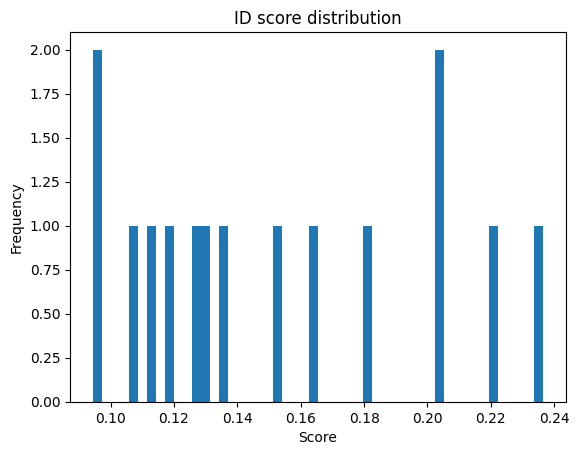

In [16]:
import matplotlib.pyplot as plt

plt.hist(id_scores.numpy(), bins=50)
plt.title("ID score distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [18]:
ood_scores = ood_img["scores"]
ood_labels = ood_img["labels"]  # usually all same class


print("OOD stats:")
print("mean:", ood_scores.mean().item())
print("std:", ood_scores.std().item())
print("min:", ood_scores.min().item())
print("max:", ood_scores.max().item())

OOD stats:
mean: 0.9013552665710449
std: 0.13933679461479187
min: 0.5685600638389587
max: 1.2045447826385498


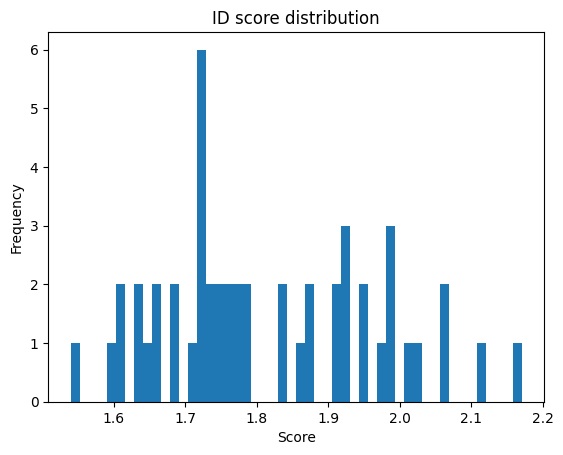

In [23]:
import matplotlib.pyplot as plt

plt.hist(ood_scores.numpy(), bins=50)
plt.title("ID score distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

### Debug inspection

In [19]:
sid = scores_id_test.numpy()
sood = scores_ood_test.numpy()

print("ID  mean/std:", sid.mean(), sid.std(), "min/max:", sid.min(), sid.max())
print("OOD mean/std:", sood.mean(), sood.std(), "min/max:", sood.min(), sood.max())

ID  mean/std: 0.15251966 0.09798692 min/max: 0.048754685 1.0130271
OOD mean/std: 0.90135527 0.5588515 min/max: 0.2412333 4.7619886


In [20]:
import matplotlib.pyplot as plt
import torch

def show_id_ood_samples(id_loader, ood_loader, num_rows=3, num_cols=6):
    """
    Visualize ID vs OOD samples.
    
    Each row:
        left half  -> ID samples
        right half -> OOD samples
    """
    fig, axes = plt.subplots(num_rows, num_cols * 2, figsize=(3 * num_cols, 3 * num_rows))

    id_iter = iter(id_loader)
    ood_iter = iter(ood_loader)

    for row in range(num_rows):
        try:
            id_batch = next(id_iter)
        except StopIteration:
            id_iter = iter(id_loader)
            id_batch = next(id_iter)

        try:
            ood_batch = next(ood_iter)
        except StopIteration:
            ood_iter = iter(ood_loader)
            ood_batch = next(ood_iter)

        id_imgs = id_batch["image"]
        ood_imgs = ood_batch["image"]

        for col in range(num_cols):
            # --- ID ---
            ax = axes[row, col]
            img = id_imgs[col]

            img = img.permute(1, 2, 0).cpu().numpy()  # [H, W, C]

            if img.shape[2] == 1:
                ax.imshow(img.squeeze(-1), cmap="gray")
            else:
                ax.imshow(img)

            ax.set_title(f"ID\n{str(id_batch['domain'][col])}")
            ax.axis("off")

            # --- OOD ---
            ax = axes[row, col + num_cols]
            img = ood_imgs[col]

            img = img.permute(1, 2, 0).cpu().numpy()

            if img.shape[2] == 1:
                ax.imshow(img.squeeze(-1), cmap="gray")
            else:
                ax.imshow(img)

            ax.set_title(f"OOD\n{str(ood_batch['domain'][col])}")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

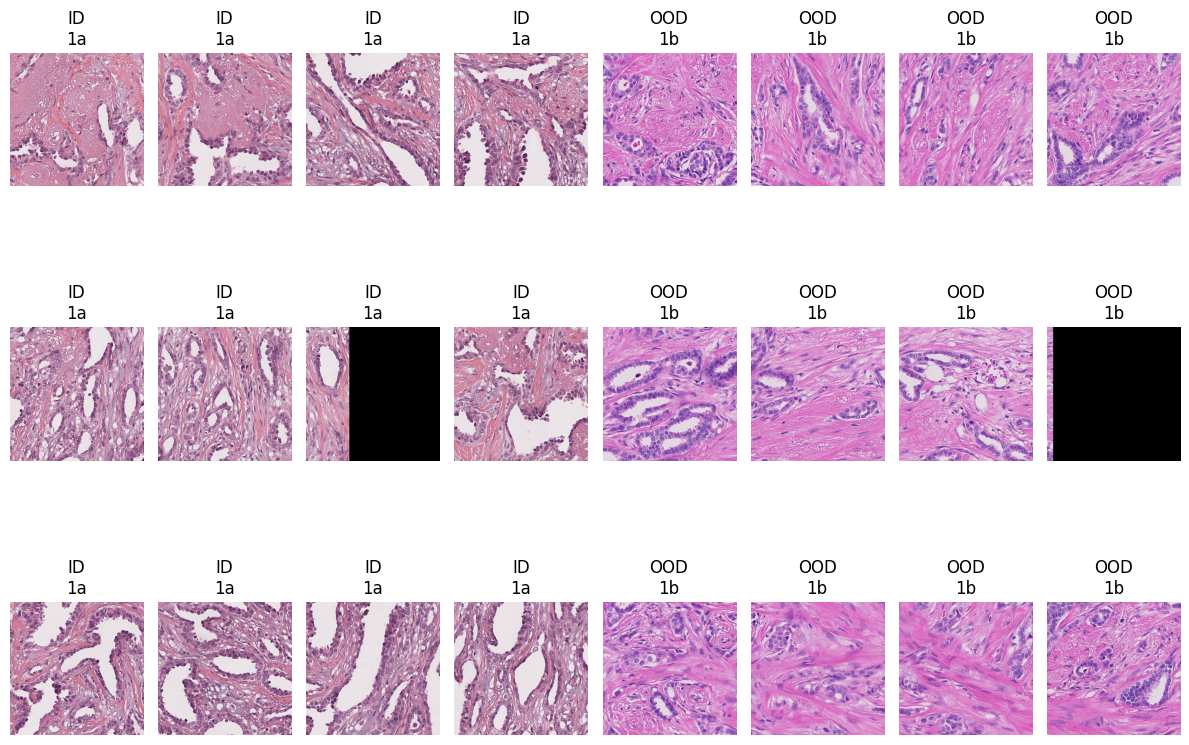

In [21]:
show_id_ood_samples(id_train_loader, ood_test_loader, num_rows=3, num_cols=4)